# Both collinear and non-collinear formalism

The default mean-field decoupling of the Hubbard $U$ term is rotationally invariant (non-collinear):
it includes both the $S^zS^z$ term (collinear, giving magnetization along $z$ only) and the
$S^+S^-$ term (allowing the local moment to cant away from $z$). With no external field, a
collinear antiferromagnet on the square lattice emerges; adding an external Zeeman field that
competes with the antiferromagnetic correlations cants the moments into a non-collinear texture.

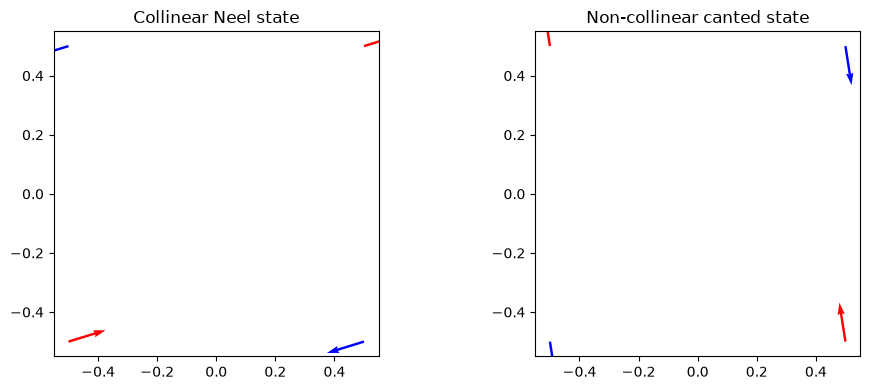

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
g = geometry.square_lattice()
g = g.get_supercell([2,2])

# collinear: pure Neel antiferromagnet, no external field
h = g.get_hamiltonian()
h = h.get_mean_field_hamiltonian(U=2.0,filling=0.5,mf="random")
m_collinear = h.get_magnetization()

# non-collinear: an external in-plane-competing Zeeman field cants the moments
h2 = g.get_hamiltonian()
h2.add_zeeman([0.,0.,0.1])
h2 = h2.get_mean_field_hamiltonian(U=2.0,filling=0.5,mf="random")
m_noncollinear = h2.get_magnetization()

fig,axs = plt.subplots(1,2,figsize=(10,4),subplot_kw=dict())
r = h.geometry.r
axs[0].quiver(r[:,0],r[:,1],m_collinear[:,0],m_collinear[:,1],
              m_collinear[:,2],cmap="bwr",scale=3)
axs[0].set_title("Collinear Neel state") ; axs[0].set_aspect("equal")
axs[1].quiver(r[:,0],r[:,1],m_noncollinear[:,0],m_noncollinear[:,1],
              m_noncollinear[:,2],cmap="bwr",scale=3)
axs[1].set_title("Non-collinear canted state") ; axs[1].set_aspect("equal")
plt.tight_layout()
plt.show()